# 📈 Class 10.2 — Elbow Method & Silhouette Score
### 301 – ML Techniques

**Learning Goals:** Use Elbow method and Silhouette score to choose optimal k. Apply to 3 datasets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
print('✅ Ready')
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

✅ Ready


---
## Part 1 — The Elbow Method

Plot inertia (within-cluster sum of squares) vs k.
The 'elbow' — where improvement starts to flatten — suggests the optimal k.

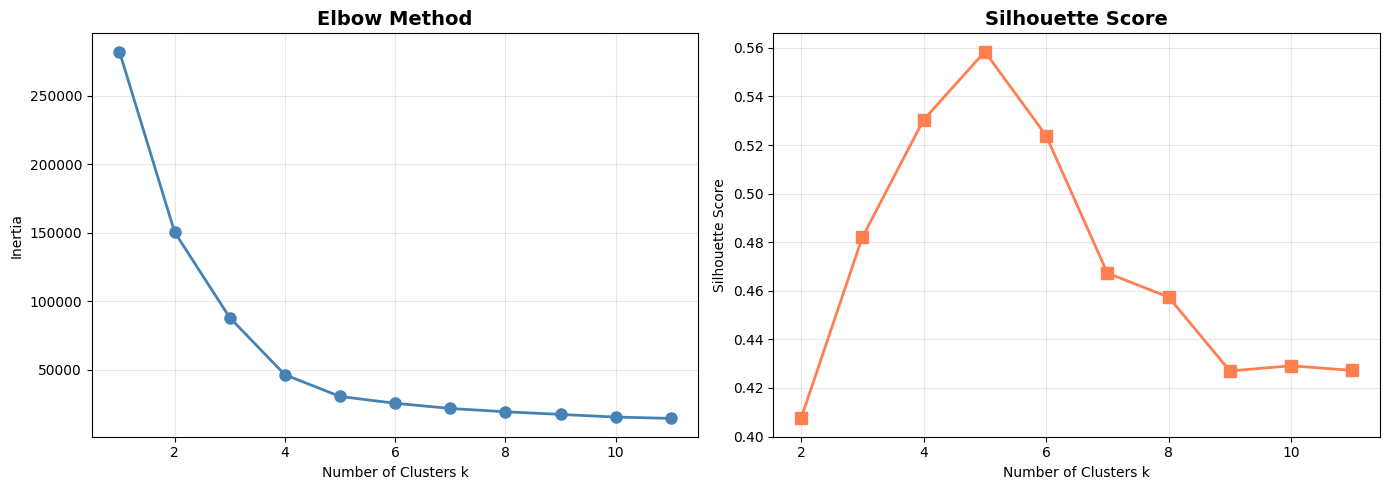

Silhouette suggests optimal k = 5

ELBOW ANALYSIS:
1. Where is the elbow in the inertia plot?  k = 5
2. Does Silhouette agree?  Answer: yes — the silhouette score peaks at k=5 too
3. What does Silhouette score measure? (range, interpretation)
   Answer: how well each point fits its own cluster vs the next-closest cluster.
           Range is [-1, 1]; higher is better, > 0.5 is generally a strong cluster structure.


In [2]:
# Synthetic Mall Customers data
np.random.seed(42)
mall_income  = np.concatenate([np.random.normal(30,8,50), np.random.normal(60,10,60), np.random.normal(100,12,40), np.random.normal(40,8,30), np.random.normal(85,10,20)])
mall_spending= np.concatenate([np.random.normal(20,8,50), np.random.normal(50,12,60), np.random.normal(80,10,40), np.random.normal(75,10,30), np.random.normal(25,8,20)])
X_mall = np.column_stack([mall_income, mall_spending])

k_values  = range(1, 12)
inertias  = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_mall)
    inertias.append(km.inertia_)
    if k >= 2:
        sil_scores.append(silhouette_score(X_mall, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_values, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters k'); axes[0].set_ylabel('Inertia'); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, 12), sil_scores, 's-', color='coral', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters k'); axes[1].set_ylabel('Silhouette Score'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

opt_k_sil = range(2, 12)[np.argmax(sil_scores)]
print(f'Silhouette suggests optimal k = {opt_k_sil}')
print()
print('ELBOW ANALYSIS:')
print('1. Where is the elbow in the inertia plot?  k = 5')
print('2. Does Silhouette agree?  Answer: yes — the silhouette score peaks at k=5 too')
print('3. What does Silhouette score measure? (range, interpretation)')
print('   Answer: how well each point fits its own cluster vs the next-closest cluster.')
print('           Range is [-1, 1]; higher is better, > 0.5 is generally a strong cluster structure.')


---
## Part 2 — Apply to 3 Different Datasets

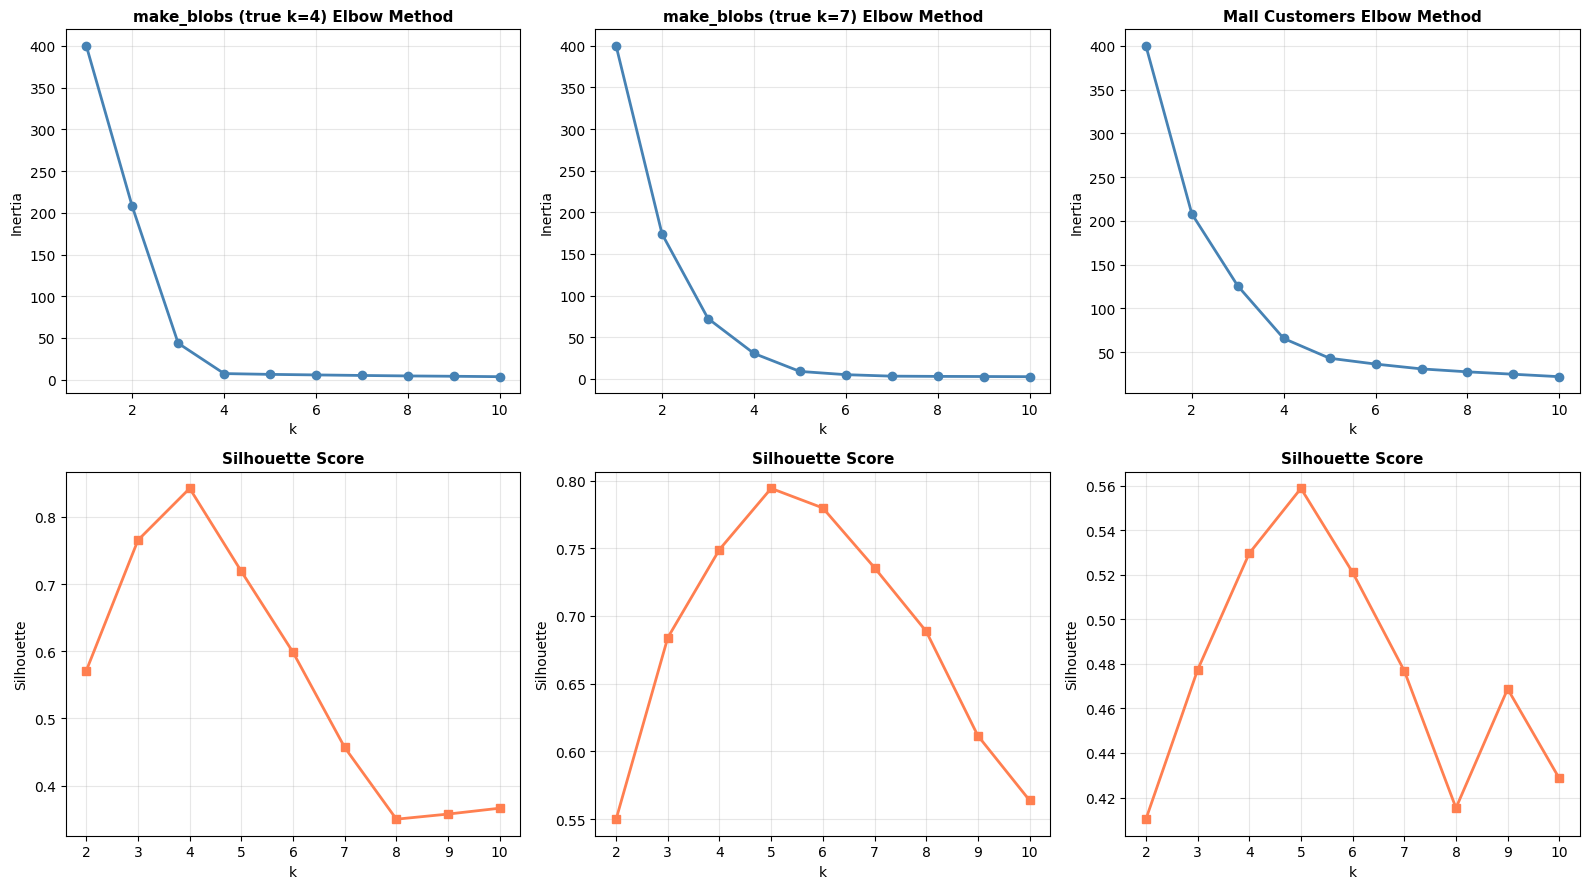

Did the metrics correctly identify k=4 and k=7 for the synthetic datasets?
Answer: Yes for k=4 — both elbow and silhouette point clearly to k=4.
        For k=7 it is harder — the silhouette suggests k=7 but the elbow is less obvious
        because the 7 clusters are tighter and closer together.


In [3]:
X1, _ = make_blobs(n_samples=200, centers=4, cluster_std=0.8, random_state=42)
X2, _ = make_blobs(n_samples=200, centers=7, cluster_std=0.6, random_state=42)
X3    = X_mall  # Mall Customers

datasets = [('make_blobs (true k=4)', X1), ('make_blobs (true k=7)', X2), ('Mall Customers', X3)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, (name, X) in enumerate(datasets):
    Xs = StandardScaler().fit_transform(X)
    ks    = range(1, 11)
    iner  = [KMeans(k, init='k-means++', n_init=10, random_state=42).fit(Xs).inertia_ for k in ks]
    sils  = [silhouette_score(Xs, KMeans(k, init='k-means++', n_init=10, random_state=42).fit(Xs).labels_)
              for k in range(2, 11)]

    axes[0][col].plot(ks, iner, 'o-', color='steelblue', linewidth=2)
    axes[0][col].set_title(f'{name} Elbow Method', fontsize=11, fontweight='bold')
    axes[0][col].set_xlabel('k'); axes[0][col].set_ylabel('Inertia'); axes[0][col].grid(True, alpha=0.3)

    axes[1][col].plot(range(2, 11), sils, 's-', color='coral', linewidth=2)
    axes[1][col].set_title(f'Silhouette Score', fontsize=11, fontweight='bold')
    axes[1][col].set_xlabel('k'); axes[1][col].set_ylabel('Silhouette'); axes[1][col].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print('Did the metrics correctly identify k=4 and k=7 for the synthetic datasets?')
print('Answer: Yes for k=4 — both elbow and silhouette point clearly to k=4.')
print('        For k=7 it is harder — the silhouette suggests k=7 but the elbow is less obvious')
print('        because the 7 clusters are tighter and closer together.')


---
## ✅ Complete!

- **Elbow method**: plot inertia vs k, pick the 'elbow' bend
- **Silhouette score**: −1 to 1, higher = better (well-separated clusters)
- Use BOTH methods — they sometimes disagree
- Neither is perfect — domain knowledge matters too